In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the catalog file
file_path = 'Abell370_catalog.cat'
df = pd.read_csv(
    input_file,
    delim_whitespace=True,
    comment="#",
    header=None,
    dtype=str
)
df.head()


/tmp/ipykernel_6629/97512828.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,1,EXTERN,CORE,39.965996,-1.5843845,6.2855000495910645,2,99.99,0.0,99.99,...,0.0,99.99,0.0,99.99,0.0,99.99,0.0,99.99,0.0,36.2
1,1,PRIOR,P02,39.9925927,-1.5675684,0.36739,3,22.554893,0.048622023,21.038517,...,0.015906025,19.752165,0.027928123,19.499338,0.011920747,19.340239,0.074522756,19.253384,0.04949513,NaN
2,1,PRIOR,P04,39.9651994,-1.5517745,0.37291,3,24.28111,0.06511242,22.340984,...,0.013656785,20.945648,0.17556329,20.705376,0.050229367,20.57675,0.12553462,20.465744,0.22816773,NaN
3,1,MUSELET,P05,39.9928256,-1.5719495,1.26522,2,99.99,99.99,99.99,...,99.99,99.99,99.99,99.99,99.99,99.99,99.99,99.99,99.99,NaN
4,2,EXTERN,CORE,39.9631884,-1.5660457,1.0322999954223633,2,99.99,0.0,99.99,...,0.0,99.99,0.0,99.99,0.0,99.99,0.0,99.99,0.0,42.2


In [10]:
allowed_pairs = [
    (101, "P03"),
    (151, "P05"),
    (202, "P10"),
    (212, "P01"),
    (285, "P10"),
    (407, "P04"),
    (459, "P02"),
    (553, "P07"),
    (590, "P05"),
    (680, "P03"),
    (812, "P04"),
    (1081, "P06"),
    (1086, "P06"),
    (1103, "P02"),
    (1233, "P08"),
    (1483, "P03"),
]



In [14]:

input_file = 'Abell370_catalog.cat'
output_file = '2my_galaxies_catalog.cat'

# Read catalog
df = pd.read_csv(input_file, delim_whitespace=True, comment='#', header=None)

# Convert allowed pairs into a DataFrame
allowed_df = pd.DataFrame(allowed_pairs, columns=[0, 2])

# Inner join to enforce (ID, Field) matching
filtered = df.merge(allowed_df, on=[0, 2], how="inner")

# Write filtered catalog
filtered.to_csv(output_file, sep=" ", header=False, index=False)


/tmp/ipykernel_6629/1837944891.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(input_file, delim_whitespace=True, comment='#', header=None)


/tmp/ipykernel_6629/3186376163.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('2my_galaxies_catalog.cat', delim_whitespace=True, comment='#', header=None)


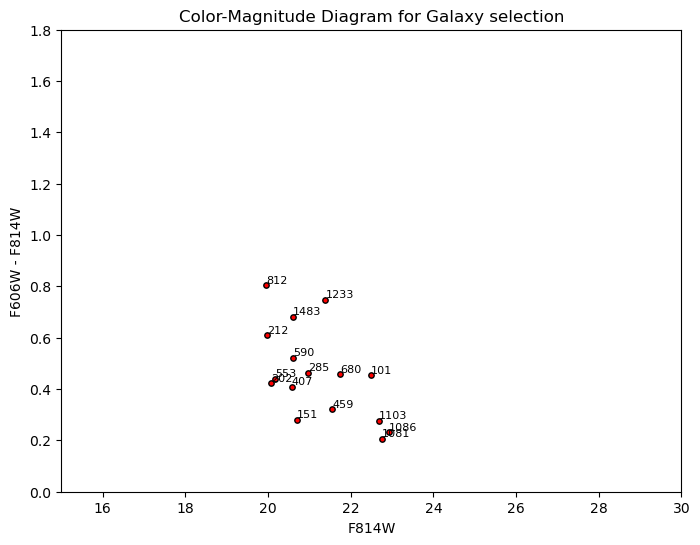

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('2my_galaxies_catalog.cat', delim_whitespace=True, comment='#', header=None)

ids = [101, 151, 202, 212, 285, 407, 459, 553, 590, 680, 812, 1081, 1086, 1103, 1233, 1483]
sub = df[df[0].isin(ids)]

# Assume F606W = col10, F814W = col12
F606W = sub[9]
F814W = sub[11]

color_index = F606W - F814W

plt.figure(figsize=(8, 6))
plt.scatter(
    F814W, 
    color_index, 
    s=15,            # marker size
    color='red',     # marker color
    edgecolors='black',  # optional: outline color
    marker='o'
)
# Label each point with its ID
for _, row in sub.iterrows():
    x = row[11]          # F814W
    y = row[9] - row[11] # F606W - F814W
    obj_id = int(row[0])
    plt.text(x, y, str(obj_id), fontsize=8, ha='left', va='bottom')
plt.xlabel("F814W")
plt.ylabel("F606W - F814W")
plt.ylim(0,1.8)
plt.xlim(15,30)
plt.title("Color-Magnitude Diagram for Galaxy selection")
#plt.gca().invert_xaxis()
#plt.gca().invert_yaxis()
plt.show()


/tmp/ipykernel_13754/786995320.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, comment='#', header=None)


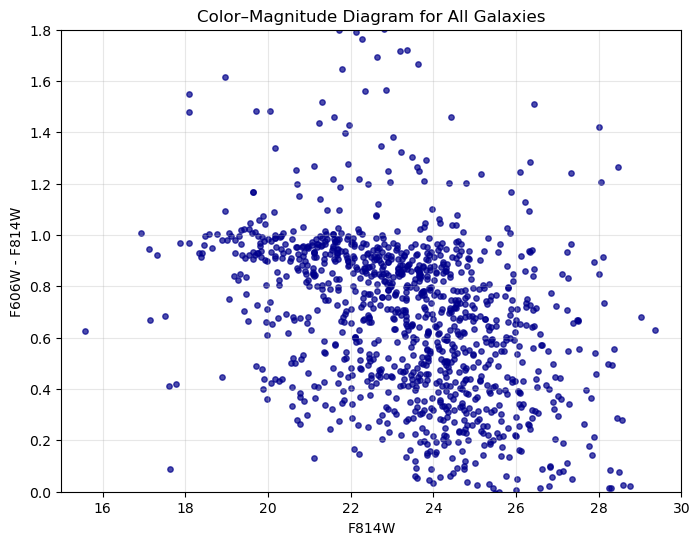

In [65]:

file_path = "Abell370_catalog.cat"
df = pd.read_csv(file_path, delim_whitespace=True, comment='#', header=None)
#filter cluster redshifts


F606W = df[9]
F814W = df[11]

color = F606W - F814W

plt.figure(figsize=(8, 6))
plt.scatter(F814W, color, s=15, color='darkblue', alpha=0.7)

plt.ylim(0,1.8)
plt.xlim(15,30)


plt.xlabel("F814W")
plt.ylabel("F606W - F814W")
plt.title("Color–Magnitude Diagram for All Galaxies")

#plt.gca().invert_xaxis()
#plt.gca().invert_yaxis()

plt.grid(alpha=0.3)
#plt.tight_layout()
plt.show()


/tmp/ipykernel_6629/3288112772.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Saved 413 galaxies to Abell370_catalog_z035_040.cat


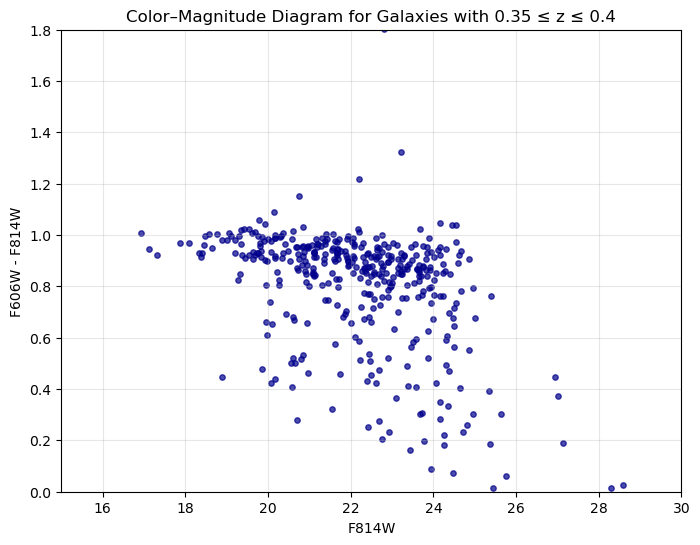

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Read catalog ----
file_path = "Abell370_catalog.cat"
df = pd.read_csv(
    file_path,
    delim_whitespace=True,
    comment="#",
    header=None
)

# ---- Columns ----
F606W_col = 9
F814W_col = 11
z_col = 5

# ---- Redshift filter ----
z_mask = (df[z_col] >= 0.35) & (df[z_col] <= 0.4)
df_z = df[z_mask].copy()

# ---- Save filtered catalog ----
output_file = "Abell370_catalog_z035_040.cat"
df_z.to_csv(
    output_file,
    sep=" ",
    header=False,
    index=False
)

print(f"Saved {len(df_z)} galaxies to {output_file}")

# ---- Compute colors for plotting ----
F606W_z = df_z[F606W_col]
F814W_z = df_z[F814W_col]
color_z = F606W_z - F814W_z

# ---- Plot ----
plt.figure(figsize=(8, 6))
plt.scatter(F814W_z, color_z, s=15, color="darkblue", alpha=0.7)

plt.xlim(15, 30)
plt.ylim(0, 1.8)

plt.xlabel("F814W")
plt.ylabel("F606W - F814W")
plt.title("Color–Magnitude Diagram for Galaxies with 0.35 ≤ z ≤ 0.4")

plt.grid(alpha=0.3)
plt.show()


/tmp/ipykernel_16628/3563401614.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Saved 314 galaxies to Abell370_catalog_z035_040_zconf3.cat


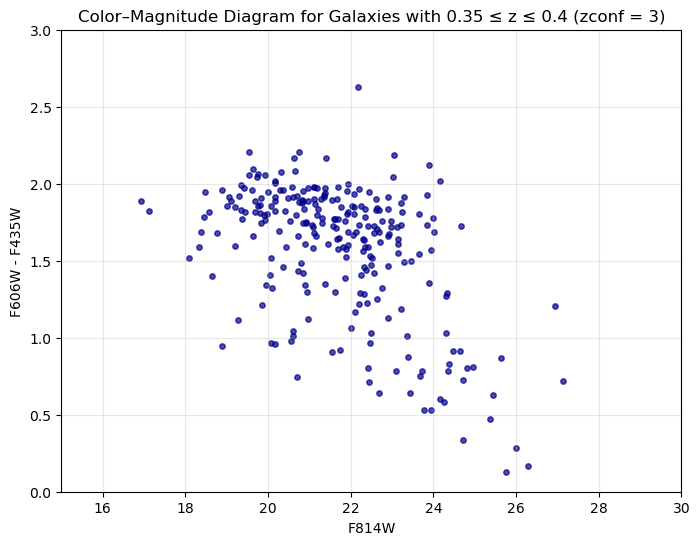

In [6]:
# color geändertt!


import pandas as pd
import matplotlib.pyplot as plt

# ---- Read catalog ----
file_path = "Abell370_catalog.cat"
df = pd.read_csv(
    file_path,
    delim_whitespace=True,
    comment="#",
    header=None
)

# ---- Columns ----
F606W_col = 9
F435W_col = 7
F814W_col = 11
z_col = 5
zconf_col = 6

# ---- Redshift + zconf filter ----
mask = (
    (df[z_col] >= 0.35) &
    (df[z_col] <= 0.4) &
    (df[zconf_col] == 3)
)

df_z = df[mask].copy()

# ---- Save filtered catalog ----
output_file = "Abell370_catalog_z035_040_zconf3.cat"
df_z.to_csv(
    output_file,
    sep=" ",
    header=False,
    index=False
)

print(f"Saved {len(df_z)} galaxies to {output_file}")

# ---- Compute colors for plotting ----
F606W_z = df_z[F606W_col]
F814W_z = df_z[F814W_col]
F435W_z = df_z[F435W_col]
color_z = F435W_z - F606W_z

# ---- Plot ----
plt.figure(figsize=(8, 6))
plt.scatter(F814W_z, color_z, s=15, color="darkblue", alpha=0.7)

plt.xlim(15, 30)
plt.ylim(0, 3)

plt.xlabel("F814W")
plt.ylabel("F606W - F435W")
plt.title("Color–Magnitude Diagram for Galaxies with 0.35 ≤ z ≤ 0.4 (zconf = 3)")

plt.grid(alpha=0.3)
plt.show()


/tmp/ipykernel_6629/292615962.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(
/tmp/ipykernel_6629/292615962.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_sel = pd.read_csv(


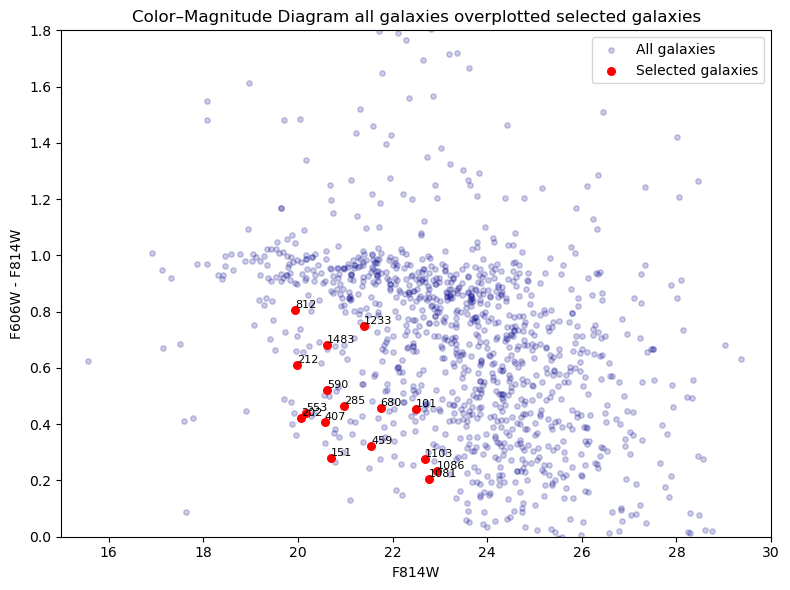

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Load main catalog (background) ----
df_all = pd.read_csv(
    "Abell370_catalog.cat",
    delim_whitespace=True,
    comment="#",
    header=None
)

# ---- Load second catalog (to overplot) ----
df_sel = pd.read_csv(
    "2my_galaxies_catalog.cat",
    delim_whitespace=True,
    comment="#",
    header=None
)

# ---- Column indices ----
F606W_col = 9
F814W_col = 11
id_col = 0

# ---- Compute colors ----
F606W_all = df_all[F606W_col]
F814W_all = df_all[F814W_col]
color_all = F606W_all - F814W_all

F606W_sel = df_sel[F606W_col]
F814W_sel = df_sel[F814W_col]
color_sel = F606W_sel - F814W_sel

# ---- Plot ----
plt.figure(figsize=(8, 6))

# All galaxies (background)
plt.scatter(
    F814W_all,
    color_all,
    s=15,
    alpha=0.2,
    color="darkblue",
    label="All galaxies"
)

# Overplotted galaxies
plt.scatter(
    F814W_sel,
    color_sel,
    s=30,
    color="red",
    label="Selected galaxies"
)

# ---- label selected galaxies ----
for _, row in df_sel.iterrows():
    x = row[F814W_col]
    y = row[F606W_col] - row[F814W_col]
    obj_id = int(row[id_col])
    plt.text(x, y, str(obj_id), fontsize=8, ha="left", va="bottom")

# ---- Axes & labels ----
plt.xlim(15, 30)
plt.ylim(0, 1.8)

plt.xlabel("F814W")
plt.ylabel("F606W - F814W")
plt.title("Color–Magnitude Diagram all galaxies overplotted selected galaxies")

plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_6629/2024861580.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(
/tmp/ipykernel_6629/2024861580.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_sel = pd.read_csv(


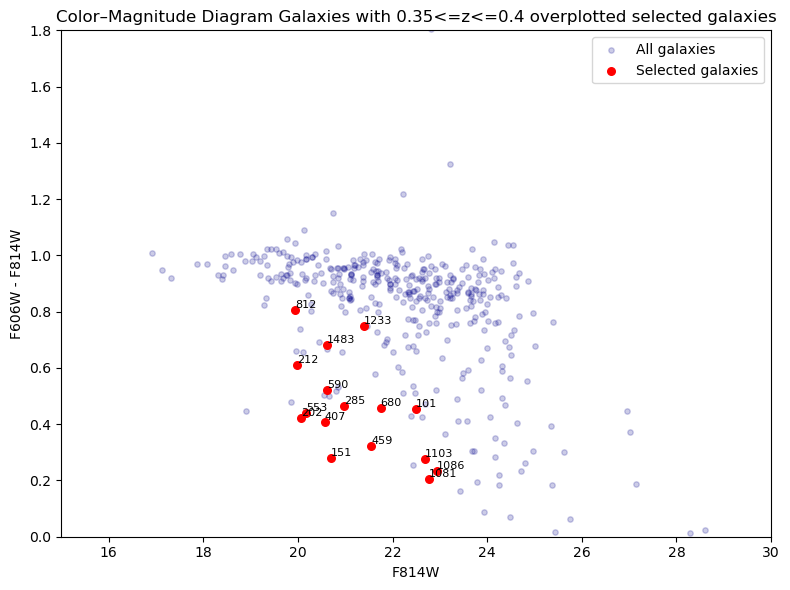

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Load main catalog (background) ----
df_all = pd.read_csv(
    "Abell370_catalog_z035_040.cat",
    delim_whitespace=True,
    comment="#",
    header=None
)

# ---- Load second catalog (to overplot) ----
df_sel = pd.read_csv(
    "2my_galaxies_catalog.cat",
    delim_whitespace=True,
    comment="#",
    header=None
)

# ---- Column indices ----
F606W_col = 9
F814W_col = 11
id_col = 0

# ---- Compute colors ----
F606W_all = df_all[F606W_col]
F814W_all = df_all[F814W_col]
color_all = F606W_all - F814W_all

F606W_sel = df_sel[F606W_col]
F814W_sel = df_sel[F814W_col]
color_sel = F606W_sel - F814W_sel

# ---- Plot ----
plt.figure(figsize=(8, 6))

# All galaxies (background)
plt.scatter(
    F814W_all,
    color_all,
    s=15,
    alpha=0.2,
    color="darkblue",
    label="All galaxies"
)

# Overplotted galaxies
plt.scatter(
    F814W_sel,
    color_sel,
    s=30,
    color="red",
    label="Selected galaxies"
)

# ---- label selected galaxies ----
for _, row in df_sel.iterrows():
    x = row[F814W_col]
    y = row[F606W_col] - row[F814W_col]
    obj_id = int(row[id_col])
    plt.text(x, y, str(obj_id), fontsize=8, ha="left", va="bottom")

# ---- Axes & labels ----
plt.xlim(15, 30)
plt.ylim(0, 1.8)

plt.xlabel("F814W")
plt.ylabel("F606W - F814W")
plt.title("Color–Magnitude Diagram Galaxies with 0.35<=z<=0.4 overplotted selected galaxies")

plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_43795/2123710743.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(
/tmp/ipykernel_43795/2123710743.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_sel = pd.read_csv(


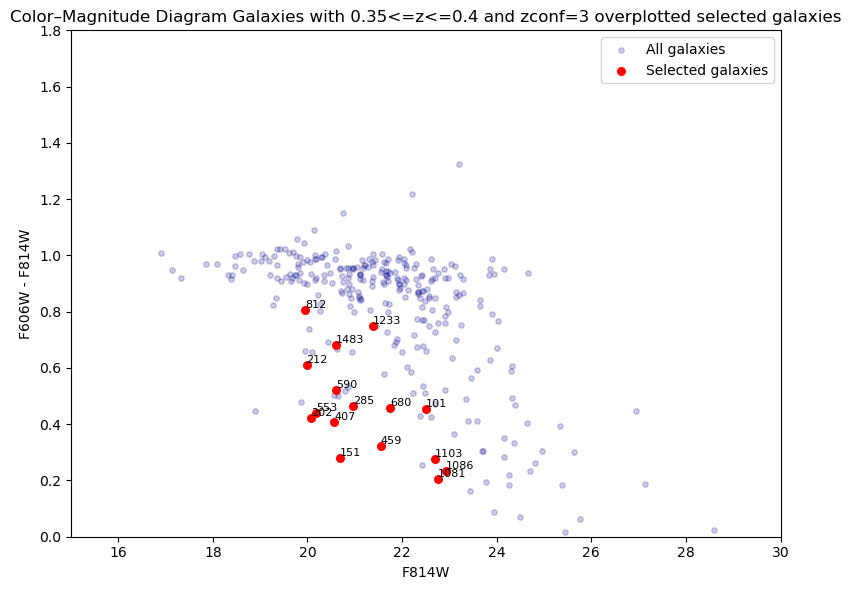

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Load main catalog (background) ----
df_all = pd.read_csv(
    "Abell370_catalog_z035_040_zconf3.cat",
    delim_whitespace=True,
    comment="#",
    header=None
)

# ---- Load second catalog (to overplot) ----
df_sel = pd.read_csv(
    "2my_galaxies_catalog.cat",
    delim_whitespace=True,
    comment="#",
    header=None
)

# ---- Column indices ----
F606W_col = 9
F814W_col = 11
id_col = 0

# ---- Compute colors ----
F606W_all = df_all[F606W_col]
F814W_all = df_all[F814W_col]
color_all = F606W_all - F814W_all

F606W_sel = df_sel[F606W_col]
F814W_sel = df_sel[F814W_col]
color_sel = F606W_sel - F814W_sel

# ---- Plot ----
plt.figure(figsize=(8, 6))

# All galaxies (background)
plt.scatter(
    F814W_all,
    color_all,
    s=15,
    alpha=0.2,
    color="darkblue",
    label="All galaxies"
)

# Overplotted galaxies
plt.scatter(
    F814W_sel,
    color_sel,
    s=30,
    color="red",
    label="Selected galaxies"
)

# ---- label selected galaxies ----
for _, row in df_sel.iterrows():
    x = row[F814W_col]
    y = row[F606W_col] - row[F814W_col]
    obj_id = int(row[id_col])
    plt.text(x, y, str(obj_id), fontsize=8, ha="left", va="bottom")

# ---- Axes & labels ----
plt.xlim(15, 30)
plt.ylim(0, 1.8)

plt.xlabel("F814W")
plt.ylabel("F606W - F814W")
plt.title("Color–Magnitude Diagram Galaxies with 0.35<=z<=0.4 and zconf=3 overplotted selected galaxies")

plt.legend()
plt.tight_layout()
plt.savefig("cluster_sample.png", dpi=300, bbox_inches="tight")
plt.show()


/tmp/ipykernel_6629/2871300644.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(cat_all, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_6629/2871300644.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_z = pd.read_csv(cat_z, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_6629/2871300644.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_zconf = pd.read_csv(cat_zconf, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_6629/2871300644.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_sel = pd.read_csv(cat_sel, delim

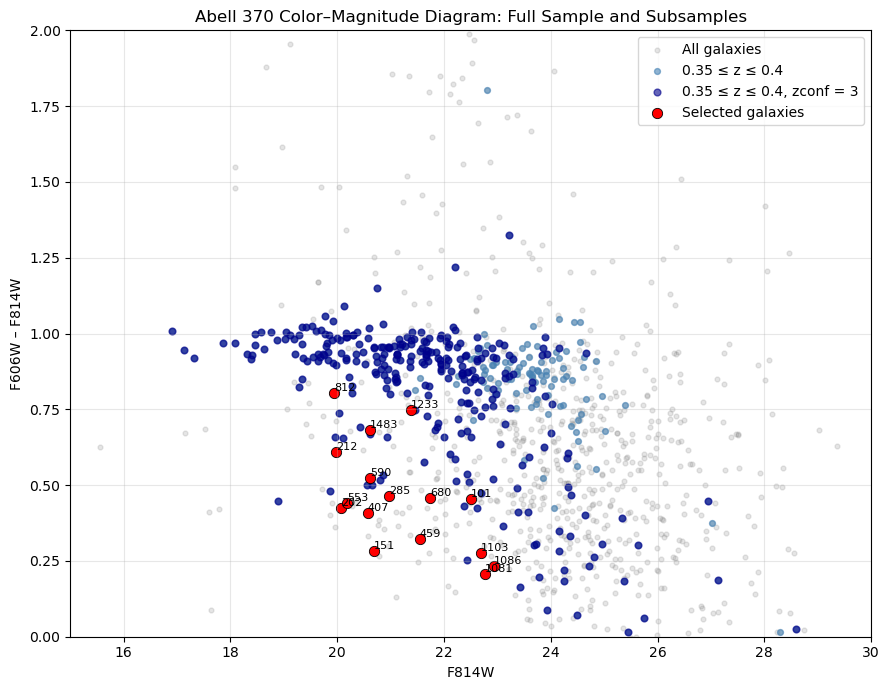

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- File paths ----
cat_all = "Abell370_catalog.cat"
cat_z = "Abell370_catalog_z035_040.cat"
cat_zconf = "Abell370_catalog_z035_040_zconf3.cat"
cat_sel = "2my_galaxies_catalog.cat"

# ---- Load catalogs ----
df_all = pd.read_csv(cat_all, delim_whitespace=True, comment="#", header=None)
df_z = pd.read_csv(cat_z, delim_whitespace=True, comment="#", header=None)
df_zconf = pd.read_csv(cat_zconf, delim_whitespace=True, comment="#", header=None)
df_sel = pd.read_csv(cat_sel, delim_whitespace=True, comment="#", header=None)

# ---- Column indices ----
F606W_col = 9
F814W_col = 11
id_col = 0

# ---- Helper: compute CMD quantities ----
def cmd_quantities(df):
    F606W = df[F606W_col]
    F814W = df[F814W_col]
    color = F606W - F814W
    return F814W, color

# ---- Compute CMD values ----
F814W_all, color_all = cmd_quantities(df_all)
F814W_z, color_z = cmd_quantities(df_z)
F814W_zconf, color_zconf = cmd_quantities(df_zconf)
F814W_sel, color_sel = cmd_quantities(df_sel)

# ---- Plot ----
plt.figure(figsize=(9, 7))

# 1. All galaxies (background)
plt.scatter(
    F814W_all,
    color_all,
    s=12,
    alpha=0.2,
    color="gray",
    label="All galaxies"
)

# 2. Cluster redshift selection
plt.scatter(
    F814W_z,
    color_z,
    s=18,
    alpha=0.6,
    color="steelblue",
    label="0.35 ≤ z ≤ 0.4"
)

# 3. Secure cluster members (zconf = 3)
plt.scatter(
    F814W_zconf,
    color_zconf,
    s=24,
    alpha=0.6,
    color="darkblue",
    label="0.35 ≤ z ≤ 0.4, zconf = 3"
)

# 4. Selected galaxies
plt.scatter(
    F814W_sel,
    color_sel,
    s=55,
    color="red",
    edgecolor="black",
    linewidth=0.6,
    label="Selected galaxies"
)

# ---- label selected galaxies ----
for _, row in df_sel.iterrows():
    x = row[F814W_col]
    y = row[F606W_col] - row[F814W_col]
    obj_id = int(row[id_col])
    plt.text(x, y, str(obj_id), fontsize=8, ha="left", va="bottom")

# ---- Axes & formatting ----
plt.xlim(15, 30)
plt.ylim(0, 2)

plt.xlabel("F814W")
plt.ylabel("F606W – F814W")
plt.title("Abell 370 Color–Magnitude Diagram: Full Sample and Subsamples")

plt.legend(frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ------------ Red Sequence -----------------

import numpy as np

# ---- Use secure cluster members to define the red sequence ----
x_rs = F814W_zconf.values
y_rs = color_zconf.values

# Remove NaNs / infs
mask = np.isfinite(x_rs) & np.isfinite(y_rs)
x_rs = x_rs[mask]
y_rs = y_rs[mask]

# ---- Linear fit: color = a * mag + b ----
a, b = np.polyfit(x_rs, y_rs, 1)

# ---- Scatter around the red sequence ----
y_fit = a * x_rs + b
sigma = np.std(y_rs - y_fit)

print(f"Red sequence fit: (F606W–F814W) = {a:.3f} × F814W + {b:.3f}")
print(f"Scatter σ = {sigma:.3f}")


Red sequence fit: (F606W–F814W) = -0.301 × F814W + 5.450
Scatter σ = 17.136


Red sequence fit: (F606W–F814W) = -0.301 × F814W + 5.450
Scatter σ = 17.136


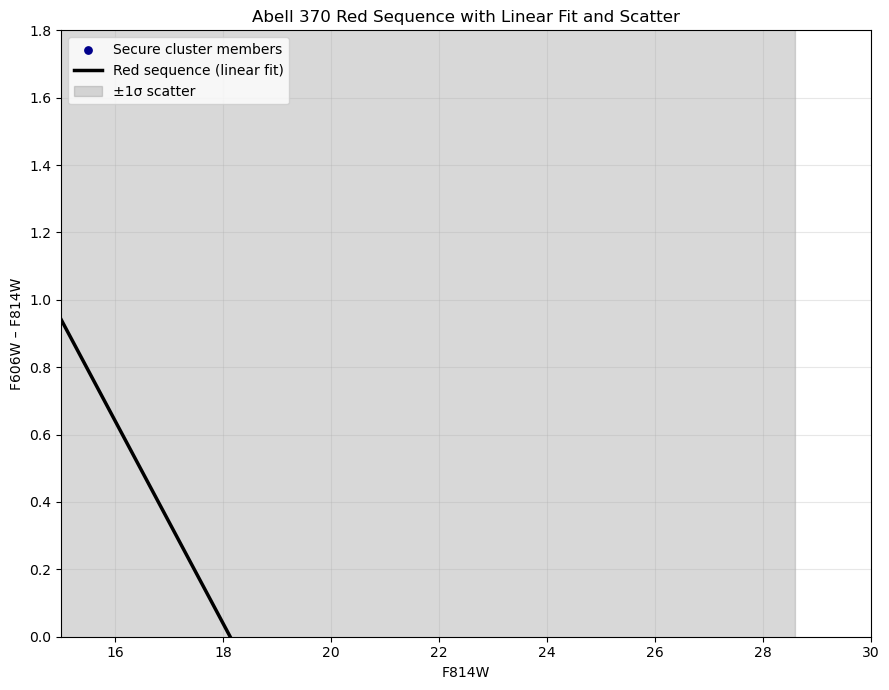

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ------------ Red Sequence -----------------

# Use secure cluster members to define the red sequence
x_rs = F814W_zconf.values
y_rs = color_zconf.values

# Remove NaNs / infs
mask = np.isfinite(x_rs) & np.isfinite(y_rs)
x_rs = x_rs[mask]
y_rs = y_rs[mask]

# Linear fit: color = a * mag + b
a, b = np.polyfit(x_rs, y_rs, 1)
y_fit = a * x_rs + b

# Scatter around the red sequence
sigma = np.std(y_rs - y_fit)

print(f"Red sequence fit: (F606W–F814W) = {a:.3f} × F814W + {b:.3f}")
print(f"Scatter σ = {sigma:.3f}")

# ---- Plot ----
plt.figure(figsize=(9, 7))

# Secure cluster members
plt.scatter(x_rs, y_rs, s=28, color="darkblue", label="Secure cluster members")

# Red sequence line
x_line = np.linspace(x_rs.min(), x_rs.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, color="black", linewidth=2.5, label="Red sequence (linear fit)")

# ±1σ scatter
plt.fill_between(x_line, y_line - sigma, y_line + sigma, color="gray", alpha=0.3, label=r"±1σ scatter")

# Axes & formatting
plt.xlabel("F814W")
plt.ylabel("F606W – F814W")
plt.title("Abell 370 Red Sequence with Linear Fit and Scatter")
plt.xlim(15, 30)
plt.ylim(0, 1.8)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ------------ Red Sequence (Bright + Color-Selected Galaxies) -----------------

# Secure cluster members
x_rs = F814W_zconf.values
y_rs = color_zconf.values

# Remove NaNs / infs
mask = np.isfinite(x_rs) & np.isfinite(y_rs)
x_rs = x_rs[mask]
y_rs = y_rs[mask]

# ---- Apply bright + color cuts ----
bright_limit = 23.5
color_min, color_max = 0.7, 1.2

selection_mask = (x_rs < bright_limit) & (y_rs >= color_min) & (y_rs <= color_max)
x_selected = x_rs[selection_mask]
y_selected = y_rs[selection_mask]

# Linear fit: color = a * mag + b
a, b = np.polyfit(x_selected, y_selected, 1)
y_fit_selected = a * x_selected + b

# Scatter around the red sequence
sigma_selected = np.std(y_selected - y_fit_selected)

print(f"Red sequence fit (bright + color-selected): (F606W–F814W) = {a:.3f} × F814W + {b:.3f}")
print(f"Scatter σ = {sigma_selected:.3f}")

# ---- Plot ----
plt.figure(figsize=(9, 7))

# All secure cluster members
plt.scatter(x_rs, y_rs, s=28, color="darkblue", label="Secure cluster members")

# Red sequence fit from bright + color-selected galaxies
x_line = np.linspace(x_rs.min(), x_rs.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, color="black", linewidth=2.5, label="Red sequence (bright + color)")

# ±1σ scatter
plt.fill_between(x_line, y_line - sigma_selected, y_line + sigma_selected,
                 color="gray", alpha=0.3, label=r"±1σ scatter")

# Axes & formatting
plt.xlabel("F814W")
plt.ylabel("F606W – F814W")
plt.title("Abell 370 Red Sequence (Bright + Color-Selected Fit)")
plt.xlim(15, 30)
plt.ylim(0, 1.8)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


TypeError: expected non-empty vector for x

/tmp/ipykernel_102883/977698808.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(cat_all, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_102883/977698808.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_z = pd.read_csv(cat_z, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_102883/977698808.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_zconf = pd.read_csv(cat_zconf, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_102883/977698808.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_sel = pd.read_csv(cat_sel, d

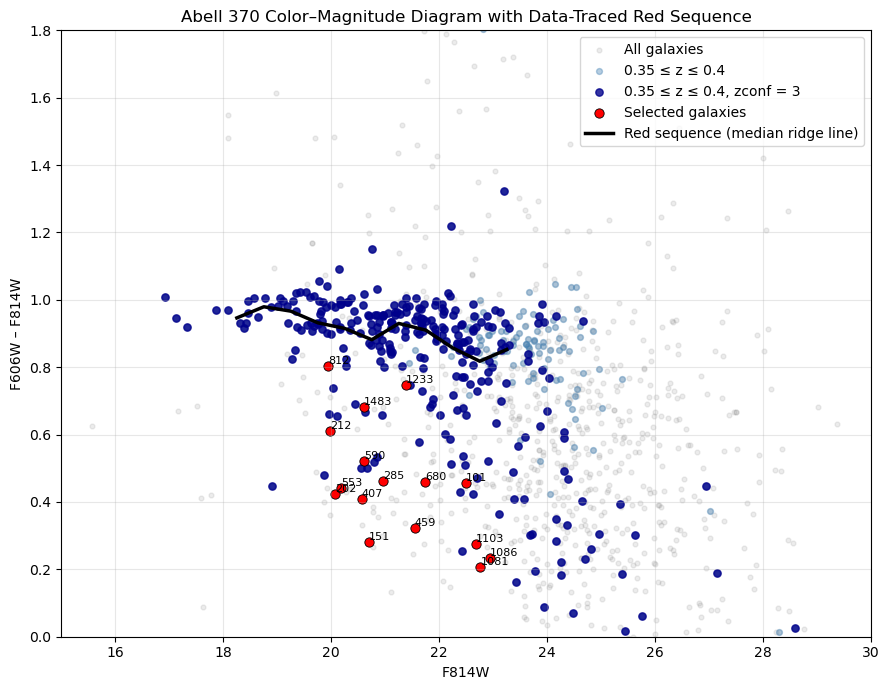

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- File paths ----
cat_all = "Abell370_catalog.cat"
cat_z = "Abell370_catalog_z035_040.cat"
cat_zconf = "Abell370_catalog_z035_040_zconf3.cat"
cat_sel = "2my_galaxies_catalog.cat"

# ---- Load catalogs ----
df_all = pd.read_csv(cat_all, delim_whitespace=True, comment="#", header=None)
df_z = pd.read_csv(cat_z, delim_whitespace=True, comment="#", header=None)
df_zconf = pd.read_csv(cat_zconf, delim_whitespace=True, comment="#", header=None)
df_sel = pd.read_csv(cat_sel, delim_whitespace=True, comment="#", header=None)

# ---- Column indices ----
F606W_col = 9
F814W_col = 11
id_col = 0

# ---- Remove invalid magnitudes ----
def clean(df):
    return df[(df[F606W_col] < 90) & (df[F814W_col] < 90)]

df_all = clean(df_all)
df_z = clean(df_z)
df_zconf = clean(df_zconf)
df_sel = clean(df_sel)

# ---- Helper: CMD quantities ----
def cmd(df):
    F814W = df[F814W_col].astype(float)
    color = df[F606W_col].astype(float) - F814W
    return F814W, color

# ---- Compute CMD values ----
F814W_all, color_all = cmd(df_all)
F814W_z, color_z = cmd(df_z)
F814W_zconf, color_zconf = cmd(df_zconf)
F814W_sel, color_sel = cmd(df_sel)

# ---- Derive red sequence from data (median ridge line) ----
# Use only secure cluster members
x = F814W_zconf.values
y = color_zconf.values

# Bin in magnitude
bins = np.arange(16, 24, 0.5)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
median_color = []

for lo, hi in zip(bins[:-1], bins[1:]):
    in_bin = (x >= lo) & (x < hi)
    if np.sum(in_bin) >= 5:        # require statistics
        median_color.append(np.median(y[in_bin]))
    else:
        median_color.append(np.nan)

median_color = np.array(median_color)

# ---- Plot ----
plt.figure(figsize=(9, 7))

# All galaxies
plt.scatter(F814W_all, color_all, s=12, alpha=0.15, color="gray", label="All galaxies")

# Cluster redshift slice
plt.scatter(F814W_z, color_z, s=18, alpha=0.4, color="steelblue",
            label="0.35 ≤ z ≤ 0.4")

# Secure cluster members
plt.scatter(F814W_zconf, color_zconf, s=28, alpha=0.8, color="darkblue",
            label="0.35 ≤ z ≤ 0.4, zconf = 3")

# Selected galaxies
plt.scatter(F814W_sel, color_sel, s=45, color="red", edgecolor="black",
            linewidth=0.6, label="Selected galaxies")

# ---- Overplot red sequence ridge line ----
plt.plot(
    bin_centers,
    median_color,
    color="black",
    linewidth=2.5,
    label="Red sequence (median ridge line)"
)

# ---- label selected galaxies ----
for _, row in df_sel.iterrows():
    x_pt = row[F814W_col]
    y_pt = row[F606W_col] - row[F814W_col]
    obj_id = int(row[id_col])
    plt.text(x_pt, y_pt, str(obj_id), fontsize=8, ha="left", va="bottom")

# ---- Axes & formatting ----
plt.xlim(15, 30)
plt.ylim(0, 1.8)

plt.xlabel("F814W")
plt.ylabel("F606W – F814W")
plt.title("Abell 370 Color–Magnitude Diagram with Data-Traced Red Sequence")

plt.legend(frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3353/1080839400.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(cat_all, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_3353/1080839400.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_z = pd.read_csv(cat_z, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_3353/1080839400.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_zconf = pd.read_csv(cat_zconf, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_3353/1080839400.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_sel = pd.read_csv(cat_sel, delim

Red sequence: color = -0.021 * F814W + 1.359, σ = 0.070


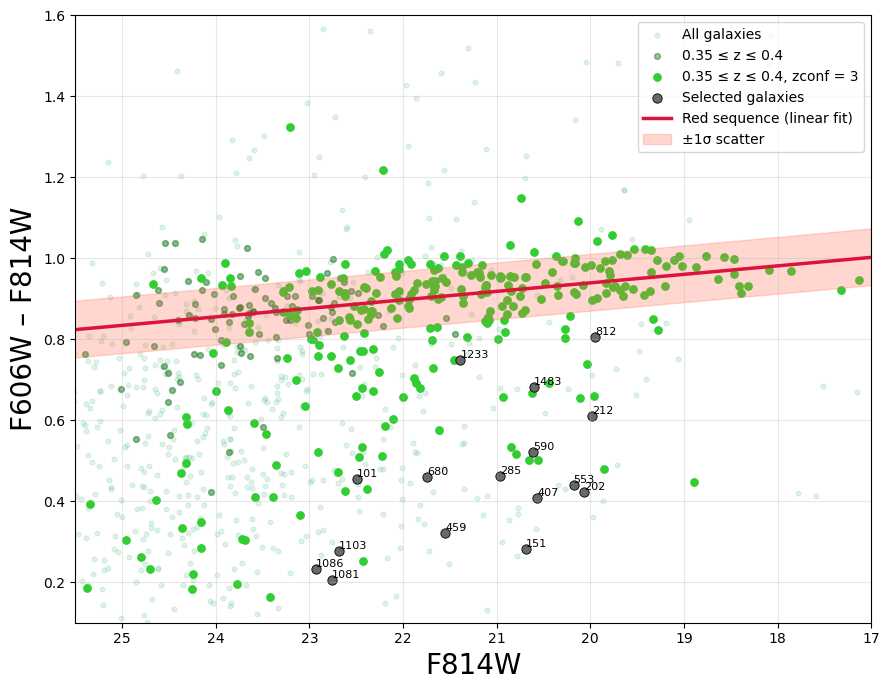

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- File paths ----
cat_all = "Abell370_catalog.cat"
cat_z = "Abell370_catalog_z035_040.cat"
cat_zconf = "Abell370_catalog_z035_040_zconf3.cat"
cat_sel = "2my_galaxies_catalog.cat"

# ---- Load catalogs ----
df_all = pd.read_csv(cat_all, delim_whitespace=True, comment="#", header=None)
df_z = pd.read_csv(cat_z, delim_whitespace=True, comment="#", header=None)
df_zconf = pd.read_csv(cat_zconf, delim_whitespace=True, comment="#", header=None)
df_sel = pd.read_csv(cat_sel, delim_whitespace=True, comment="#", header=None)

# ---- Column indices ----
F606W_col = 9
F814W_col = 11
id_col = 0

# ---- Remove invalid magnitudes ----
def clean(df):
    return df[(df[F606W_col] < 90) & (df[F814W_col] < 90)]

df_all = clean(df_all)
df_z = clean(df_z)
df_zconf = clean(df_zconf)
df_sel = clean(df_sel)

# ---- Helper: CMD quantities ----
def cmd(df):
    F814W = df[F814W_col].astype(float)
    color = df[F606W_col].astype(float) - F814W
    return F814W, color

# ---- Compute CMD values ----
F814W_all, color_all = cmd(df_all)
F814W_z, color_z = cmd(df_z)
F814W_zconf, color_zconf = cmd(df_zconf)
F814W_sel, color_sel = cmd(df_sel)

# ---- Red sequence: bright + color-selected secure members ----
x_rs = F814W_zconf.values
y_rs = color_zconf.values

# Remove NaNs / infs
mask = np.isfinite(x_rs) & np.isfinite(y_rs)
x_rs = x_rs[mask]
y_rs = y_rs[mask]

# Bright + color selection
bright_limit = 24
color_min, color_max = 0.7, 1.2
selection_mask = (x_rs < bright_limit) & (y_rs >= color_min) & (y_rs <= color_max)
x_fit = x_rs[selection_mask]
y_fit = y_rs[selection_mask]

# Linear fit
a, b = np.polyfit(x_fit, y_fit, 1)
y_fit_line = a * x_fit + b
sigma = np.std(y_fit - y_fit_line)
print(f"Red sequence: color = {a:.3f} * F814W + {b:.3f}, σ = {sigma:.3f}")

# ---- Plot ----
plt.figure(figsize=(9, 7))

# All galaxies
plt.scatter(F814W_all, color_all, s=12, alpha=0.15, color="mediumseagreen", label="All galaxies")

# Cluster redshift slice
plt.scatter(F814W_z, color_z, s=18, alpha=0.4, color="darkgreen", label="0.35 ≤ z ≤ 0.4")

# Secure cluster members
plt.scatter(F814W_zconf, color_zconf, s=28, color="limegreen", label="0.35 ≤ z ≤ 0.4, zconf = 3")

# Selected galaxies
plt.scatter(F814W_sel, color_sel, s=45, color="dimgrey", edgecolor="black",
            linewidth=0.6, label="Selected galaxies")

# ---- Red sequence line ----
x_line = np.linspace(x_rs.min(), x_rs.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, color="crimson", linewidth=2.5, label="Red sequence (linear fit)")

# ±1σ scatter
plt.fill_between(x_line, y_line - sigma, y_line + sigma, color="tomato", alpha=0.25, label=r"±1σ scatter")

# ---- label selected galaxies ----
for _, row in df_sel.iterrows():
    x_pt = row[F814W_col]
    y_pt = row[F606W_col] - row[F814W_col]
    obj_id = int(row[id_col])
    plt.text(x_pt, y_pt, str(obj_id), fontsize=8, ha="left", va="bottom")

# ---- Axes & formatting ----
plt.xlim(17, 25.5)
plt.ylim(0.1, 1.6)
plt.xlabel("F814W", fontsize=20)
plt.ylabel("F606W – F814W", fontsize=20)
#plt.title("Abell 370 Color–Magnitude Diagram with Linear Red Sequence")
plt.legend(frameon=True)
plt.grid(alpha=0.3)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig("Abell370_color_mag", dpi=300, bbox_inches="tight")
plt.show()


In [24]:

# ---- Prepare tables ----
def make_table(df, catalog_name):
    F814W = df[F814W_col].astype(float)
    color = df[F606W_col].astype(float) - F814W
    table = pd.DataFrame({
        "Catalog": catalog_name,
        "F814W": F814W,
        "F606W-F814W": color
    })
    return table

# Tables for all catalogs
table_all = make_table(df_all, "All")
table_z = make_table(df_z, "0.35 ≤ z ≤ 0.4")
table_zconf = make_table(df_zconf, "Secure zconf=3")
table_sel = make_table(df_sel, "Selected")

# Combine all into one table
full_table = pd.concat([table_all, table_z, table_zconf, table_sel], ignore_index=True)

# Print
pd.set_option("display.max_rows", None)  # show all rows
print(full_table)


             Catalog      F814W  F606W-F814W
0                All  20.060999     0.977518
1                All  21.375660     0.965324
2                All  19.331700     0.850000
3                All  17.592900     0.412704
4                All  18.633900     0.949400
5                All  19.641200     1.169300
6                All  23.225930     0.688642
7                All  22.066170     0.852714
8                All  22.619852     0.424828
9                All  22.407385     0.492535
10               All  22.482193     0.411322
11               All  21.671010     0.985608
12               All  23.349098     0.668446
13               All  22.713339     0.467243
14               All  22.656350     1.120750
15               All  23.995329     0.033943
16               All  25.084417     0.504078
17               All  24.321623     0.508468
18               All  21.952232     0.882485
19               All  21.193916     0.707016
20               All  25.218798     0.183802
21        

/tmp/ipykernel_102883/1246249979.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(cat_all, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_102883/1246249979.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_z = pd.read_csv(cat_z, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_102883/1246249979.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_zconf = pd.read_csv(cat_zconf, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_102883/1246249979.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_sel = pd.read_csv(cat_se

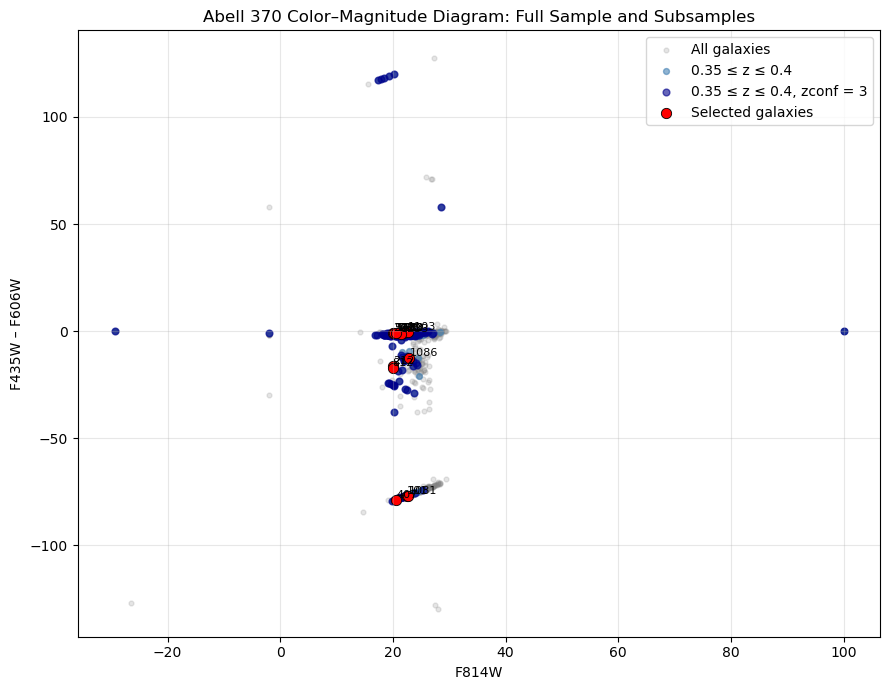

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- File paths ----
cat_all = "Abell370_catalog.cat"
cat_z = "Abell370_catalog_z035_040.cat"
cat_zconf = "Abell370_catalog_z035_040_zconf3.cat"
cat_sel = "2my_galaxies_catalog.cat"

# ---- Load catalogs ----
df_all = pd.read_csv(cat_all, delim_whitespace=True, comment="#", header=None)
df_z = pd.read_csv(cat_z, delim_whitespace=True, comment="#", header=None)
df_zconf = pd.read_csv(cat_zconf, delim_whitespace=True, comment="#", header=None)
df_sel = pd.read_csv(cat_sel, delim_whitespace=True, comment="#", header=None)

# ---- Column indices ----
F435W_col = 7
F606W_col = 9
F814W_col = 11
id_col = 0

# ---- Helper: compute CMD quantities ----
def cmd_quantities(df):
    F606W = df[F606W_col]
    F435W = df[F435W_col]
    F814W = df[F814W_col]
    color = F606W - F435W
    return F814W, color

# ---- Compute CMD values ----
F814W_all, color_all = cmd_quantities(df_all)
F814W_z, color_z = cmd_quantities(df_z)
F814W_zconf, color_zconf = cmd_quantities(df_zconf)
F814W_sel, color_sel = cmd_quantities(df_sel)

# ---- Plot ----
plt.figure(figsize=(9, 7))

# 1. All galaxies (background)
plt.scatter(
    F814W_all,
    color_all,
    s=12,
    alpha=0.2,
    color="gray",
    label="All galaxies"
)

# 2. Cluster redshift selection
plt.scatter(
    F814W_z,
    color_z,
    s=18,
    alpha=0.6,
    color="steelblue",
    label="0.35 ≤ z ≤ 0.4"
)

# 3. Secure cluster members (zconf = 3)
plt.scatter(
    F814W_zconf,
    color_zconf,
    s=24,
    alpha=0.6,
    color="darkblue",
    label="0.35 ≤ z ≤ 0.4, zconf = 3"
)

# 4. Selected galaxies
plt.scatter(
    F814W_sel,
    color_sel,
    s=55,
    color="red",
    edgecolor="black",
    linewidth=0.6,
    label="Selected galaxies"
)

# ---- label selected galaxies ----
for _, row in df_sel.iterrows():
    x = row[F814W_col]
    y = row[F606W_col] - row[F435W_col]
    obj_id = int(row[id_col])
    plt.text(x, y, str(obj_id), fontsize=8, ha="left", va="bottom")

# ---- Axes & formatting ----
#plt.xlim(15, 30)
#plt.ylim(0, 2)

plt.xlabel("F814W")
plt.ylabel("F435W – F606W")
plt.title("Abell 370 Color–Magnitude Diagram: Full Sample and Subsamples")

plt.legend(frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:

# ---- Prepare tables ----
def make_table(df, catalog_name):
    F814W = df[F814W_col].astype(float)
    color = df[F435W_col].astype(float) - df[F606W_col].astype(float) 
    table = pd.DataFrame({
        "Catalog": catalog_name,
        "F814W": F814W,
        "F435W-F606W": color
    })
    return table

# Tables for all catalogs
table_all = make_table(df_all, "All")
table_z = make_table(df_z, "0.35 ≤ z ≤ 0.4")
table_zconf = make_table(df_zconf, "Secure zconf=3")
table_sel = make_table(df_sel, "Selected")

# Combine all into one table
full_table = pd.concat([table_all, table_z, table_zconf, table_sel], ignore_index=True)

# Print
pd.set_option("display.max_rows", None)  # show all rows
print(full_table)


             Catalog      F814W  F435W-F606W
0                All  20.060999     1.516376
1                All  21.375660     1.940126
2                All  19.331700  -119.181700
3                All  17.592900     0.344780
4                All  18.633900     1.398900
5                All  19.641200     2.005000
6                All  23.225930    11.855356
7                All  22.066170     1.668006
8                All  22.619852    11.932314
9                All  22.407385    27.889700
10               All  22.482193    13.342352
11               All  21.671010     1.946936
12               All  23.349098    23.366236
13               All  22.713339    18.600943
14               All  22.656350     0.679150
15               All  23.995329    19.284655
16               All  25.084417    26.136069
17               All  24.321623    12.470427
18               All  21.952232    13.765850
19               All  21.193916    30.530268
20               All  25.218798    13.665626
21        